Imports

In [6]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


Load data

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


data normalization(data scalling)

In [19]:
x_train = x_train/255
x_test = x_test/255

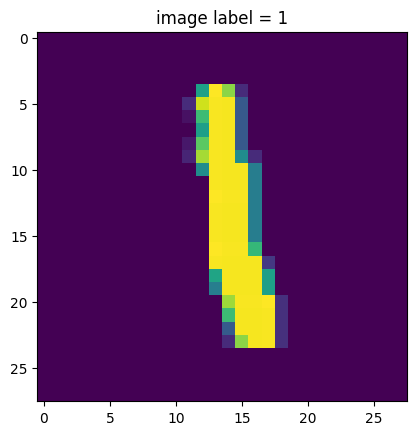

In [20]:
#print(x_train[6])
#print(y_train[6])
plt.imshow(x_train[6])
plt.title(f"image label = {y_train[6]}")
plt.show()

model creation

In [32]:
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes= 10)
y_test = to_categorical(y_test, num_classes= 10)

model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(5, activation="relu"),
    Dense(10, activation="softmax")
]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


model details

In [33]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,985 (15.57 KB)

 Trainable params: 3,985 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

compile model

In [34]:
model.compile(optimizer="adam", loss = "categorical_crossentropy", metrics= ['accuracy'])

train model

In [35]:

model.fit(x_train, y_train, epochs=5,batch_size=32, verbose=2)

Epoch 1/5
1875/1875 - 4s - 2ms/step - accuracy: 0.7376 - loss: 0.8395
Epoch 2/5
1875/1875 - 4s - 2ms/step - accuracy: 0.8523 - loss: 0.5096
Epoch 3/5
1875/1875 - 4s - 2ms/step - accuracy: 0.8678 - loss: 0.4617
Epoch 4/5
1875/1875 - 3s - 2ms/step - accuracy: 0.8766 - loss: 0.4368
Epoch 5/5
1875/1875 - 6s - 3ms/step - accuracy: 0.8812 - loss: 0.4199


evaluate model

In [36]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8706 - loss: 0.4471


[0.40288376808166504, 0.8862000107765198]

save model

In [37]:
model.save("image_identification_model.h5")